# Exercise 1: Fitting a Lorentzian Peak over a Quadratic Background

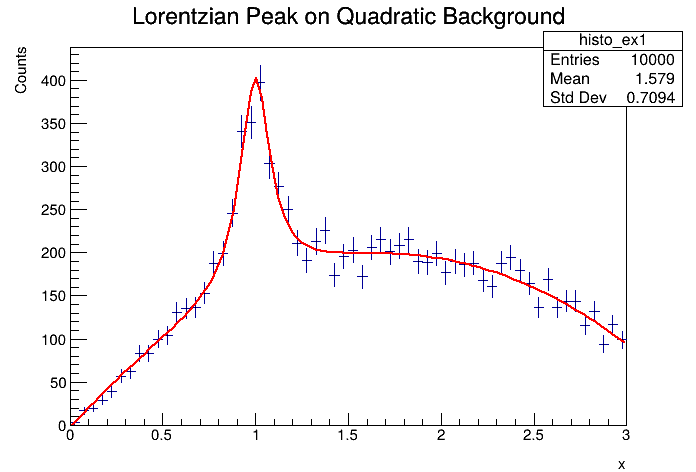

In [6]:
import ROOT
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
ROOT.gErrorIgnoreLevel = ROOT.kError
ROOT.gROOT.SetBatch(True)

data = np.loadtxt("fitting-exercise-data.txt")

h1 = ROOT.TH1D(
    name="histo_ex1", title="Lorentzian Peak on Quadratic Background",
    nbinsx=60, xlow=0, xup=3)

h1.Fill(data, np.ones(data.size))

def fitFunction(x: np.ndarray, pars: np.ndarray) -> float:
    bg = pars[0] + pars[1]*x[0] + pars[2]*x[0]*x[0]
    num = 0.5 * pars[3] * 0.2 / np.pi
    denom = max(1.e-10, (x[0] - 1.)**2 + 0.25 * 0.04)
    peak = num / denom
    return bg + peak

fitFcn = ROOT.TF1("fitFcn", fitFunction, xmin=0, xmax=3, npar=4)
h1.Fit(fitFcn, "Q")

h1.GetXaxis().SetTitle("x")
h1.GetXaxis().SetTitleOffset(1.5)
h1.GetYaxis().SetTitle("Counts")

c1 = ROOT.TCanvas()
h1.Draw("E")
c1.SaveAs("exercise1_root.png")

from IPython.display import Image, display
display(Image("exercise1_root.png"))


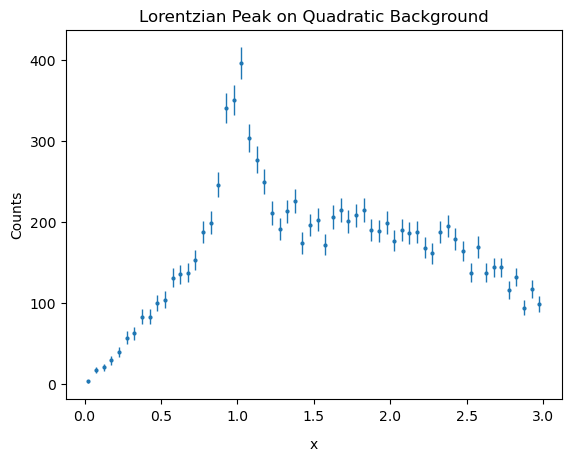

In [7]:
import mplhep as hep
import matplotlib.pyplot as plt

hep.histplot(
    h1,
    histtype="errorbar",
    markersize=4,
)
plt.title("Lorentzian Peak on Quadratic Background")
plt.xlabel("x", labelpad=10)
plt.ylabel("Counts")
plt.show()

# Exercise 2: RDataFrame Basics
The file `example_file.root` contains a TTree called `"dataset"` with two scalar columns: `a` and `b`. There is a normal distribution in the data and to show it, you need to plot the natural logarithm of `a` only for entries where `b <= 0.5`.

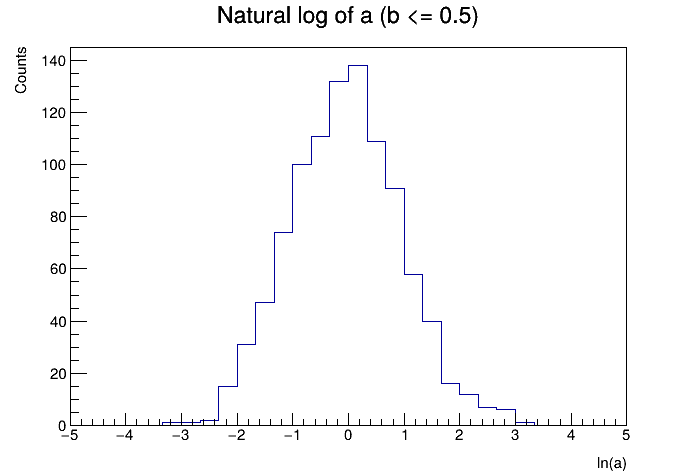

In [8]:
import ROOT
ROOT.gErrorIgnoreLevel = ROOT.kError
ROOT.gROOT.SetBatch(True)

df2 = ROOT.RDataFrame("dataset", "example_file.root")

h2 = (df2.Filter("b <= 0.5")
         .Define("loga", "TMath::Log(a)")
         .Histo1D(("h2", "Natural log of a (b <= 0.5)", 30, -5, 5), "loga"))

h2.SetStats(0)
h2.GetXaxis().SetTitle("ln(a)")
h2.GetXaxis().SetTitleOffset(1.5)
h2.GetYaxis().SetTitle("Counts")

c2 = ROOT.TCanvas()
h2.Draw()
c2.SaveAs("exercise2.png")

from IPython.display import Image, display
display(Image("exercise2.png"))

# Exercise 3: RDataFrame and Collections
The same dataset from Exercise 2 has two vector columns: `vec1` and `vec2`. The entries of `vec1` are distributed as a mixture of Gaussians + background noise. To remove the noise, select elements of `vec1` where the square of the corresponding `vec2` element is less than 0.1.

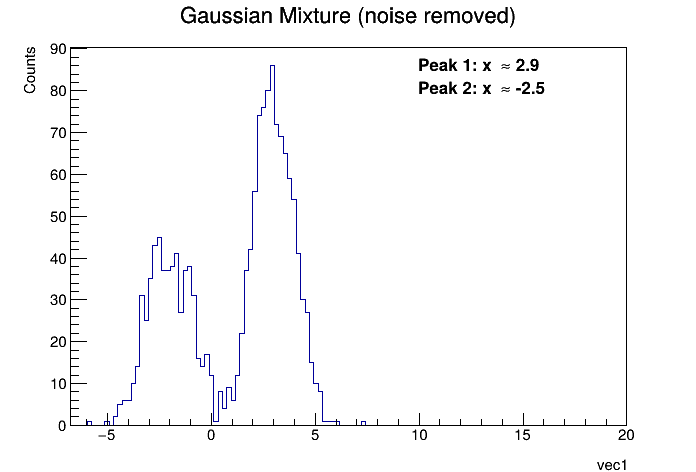

In [10]:
import ROOT
ROOT.gErrorIgnoreLevel = ROOT.kError
ROOT.gROOT.SetBatch(True)

df3 = ROOT.RDataFrame("dataset", "example_file.root")

h3 = (df3.Define("v1_to_plot", "vec1[vec2*vec2 < 0.1]")
         .Histo1D("v1_to_plot"))

h3.SetStats(0)
h3.GetXaxis().SetTitle("vec1")
h3.GetXaxis().SetTitleOffset(1.5)
h3.GetYaxis().SetTitle("Counts")
h3.SetTitle("Gaussian Mixture (noise removed)")

#peak positions
n_bins = h3.GetNbinsX()
bin_contents = [h3.GetBinContent(i) for i in range(1, n_bins + 1)]
bin_centres = [h3.GetBinCenter(i) for i in range(1, n_bins + 1)]

#two highest bins
sorted_bins = sorted(zip(bin_contents, bin_centres), reverse=True)
peak1 = sorted_bins[0][1]
peak2 = None
for count, centre in sorted_bins[1:]:
    if abs(centre - peak1) > 2:  # must be at least 2 apart
        peak2 = centre
        break

c3 = ROOT.TCanvas()
h3.Draw()

text = ROOT.TLatex()
text.SetNDC()
text.SetTextSize(0.04)
text.DrawLatex(0.6, 0.85, f"Peak 1: x #approx {peak1:.1f}")
text.DrawLatex(0.6, 0.80, f"Peak 2: x #approx {peak2:.1f}")

c3.SaveAs("exercise3.png")

from IPython.display import Image, display
display(Image("exercise3.png"))